In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler

In [ ]:
# Generate a synthetic dataset for 100 houses
np.random.seed(42)
n_samples = 100
sqft = np.random.normal(2000, 500, n_samples)
bedrooms = np.random.randint(1, 6, n_samples)
age = np.random.randint(0, 50, n_samples)
# Price formula with some random noise
price = (sqft * 150) + (bedrooms * 10000) - (age * 500) + np.random.normal(0, 10000, n_samples)

df = pd.DataFrame({'sqft': sqft, 'bedrooms': bedrooms, 'age': age, 'price': price})
df.head()

,sqft,bedrooms,age,price
0,2248.357077,1,34,343562.374756
1,1930.867849,5,15,342012.203517
2,2323.844269,1,40,340899.601939
3,2761.514928,3,35,428489.048451
4,1882.923313,2,32,274912.843179


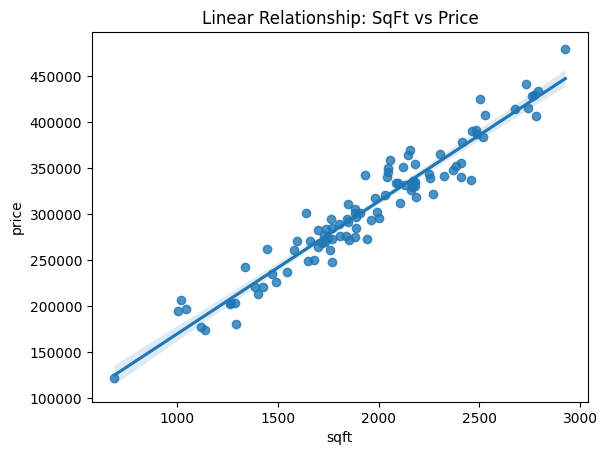

In [ ]:
sns.regplot(x='sqft', y='price', data=df)
plt.title("Linear Relationship: SqFt vs Price")
plt.show()

In [ ]:
X = df[['sqft', 'bedrooms', 'age']]
y_linear = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y_linear, test_size=0.2)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Add predictions back to the main dataframe
df['predicted_price'] = lin_reg.predict(X)

<Figure size 800x600 with 0 Axes>

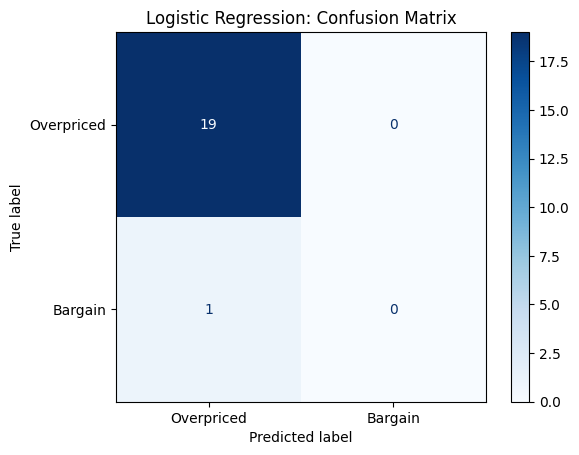

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Generate the Confusion Matrix
# 'y_test_log' are the real labels, 'y_pred' are what the model guessed
cm = confusion_matrix(y_test_log, log_reg.predict(X_test_log))

# 2. Plot it using Seaborn/Matplotlib for a professional look
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Overpriced', 'Bargain'])
disp.plot(cmap='Blues', values_format='d')

plt.title('Logistic Regression: Confusion Matrix')
plt.grid(False) # Clean up the background
plt.show()

In [ ]:
# Create target: 1 if actual price is a bargain, 0 if not
df['is_bargain'] = (df['price'] < (df['predicted_price'] * 0.95)).astype(int)

# Logistic Regression works best with scaled data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_scaled, df['is_bargain'], test_size=0.2)

log_reg = LogisticRegression()
log_reg.fit(X_train_log, y_train_log)

LogisticRegression()